# Assignment 8

## Question 1

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from sklearn.model_selection import train_test_split
import os

2026-03-19 18:37:24.699920: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### A. Load the data

In [3]:
FENCE_DIR = "../Ass7/fence_renamed"

inside_paths  = [os.path.join(FENCE_DIR, "inside",  f) for f in os.listdir(os.path.join(FENCE_DIR, "inside"))  if f.endswith(".jpg")]
outside_paths = [os.path.join(FENCE_DIR, "outside", f) for f in os.listdir(os.path.join(FENCE_DIR, "outside")) if f.endswith(".jpg")]

print(f"Inside images:  {len(inside_paths)}")
print(f"Outside images: {len(outside_paths)}")

Inside images:  467
Outside images: 524


#### Balance the binary dataset

In [4]:
n_samples = min(len(inside_paths), len(outside_paths))
inside_paths = inside_paths[:n_samples]
outside_paths = outside_paths[:n_samples]
print(f"Balanced: {n_samples} per class, {n_samples * 2} total")

Balanced: 467 per class, 934 total


### B. Preprocess images

In [5]:
IMG_SIZE = (64, 64)

original_images = []
images = []
for p in inside_paths + outside_paths:
    original = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    original_images.append(original)

    img = cv2.resize(original, IMG_SIZE)
    images.append(img)

images = np.array(images, dtype="float32") / 255.0
images = images[..., np.newaxis]  # (N, 64, 64, 1)

labels = np.array([0] * len(inside_paths) + [1] * len(outside_paths), dtype="float32")
print(f"Images shape: {images.shape}, Labels shape: {labels.shape}")

Images shape: (934, 64, 64, 1), Labels shape: (934,)


#### Split into train, validation, and test sets

In [6]:
train_data, temp_data, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.30, random_state=42, stratify=labels
)
val_data, test_data, val_labels, test_labels = train_test_split(
    temp_data, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
)

print(f"Training Data:   {len(train_data)}")
print(f"Validation Data: {len(val_data)}")
print(f"Testing Data:    {len(test_data)}")

Training Data:   653
Validation Data: 140
Testing Data:    141


#### Visualize sample images

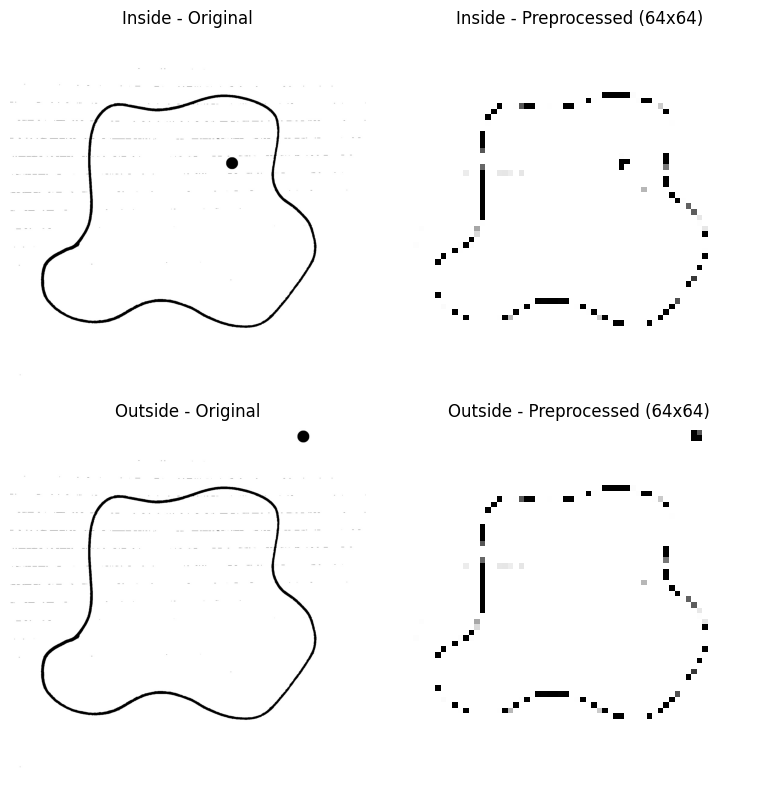

In [7]:
inside_idx = 0
outside_idx = len(inside_paths)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(original_images[inside_idx], cmap="gray")
axes[0, 0].set_title("Inside - Original")
axes[0, 0].axis("off")
axes[0, 1].imshow(images[inside_idx, ..., 0], cmap="gray")
axes[0, 1].set_title(f"Inside - Preprocessed ({IMG_SIZE[0]}x{IMG_SIZE[1]})")
axes[0, 1].axis("off")
axes[1, 0].imshow(original_images[outside_idx], cmap="gray")
axes[1, 0].set_title("Outside - Original")
axes[1, 0].axis("off")
axes[1, 1].imshow(images[outside_idx, ..., 0], cmap="gray")
axes[1, 1].set_title(f"Outside - Preprocessed ({IMG_SIZE[0]}x{IMG_SIZE[1]})")
axes[1, 1].axis("off")
plt.tight_layout()
plt.show()

#### Build the CNN Model

In [8]:
cnn_model = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

I0000 00:00:1773925663.014914  302433 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2612 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    min_delta=1e-4,
    restore_best_weights=True,
)

history_cnn = cnn_model.fit(
    train_data, train_labels,
    epochs=80,
    validation_data=(val_data, val_labels),
    callbacks=[early_stop],
    verbose=1,
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_data, test_labels, verbose=0)
print(f'CNN Test accuracy: {cnn_test_acc:.4f}')

Epoch 1/80


2026-03-19 18:37:45.257922: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f438c0044c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-19 18:37:45.257963: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2026-03-19 18:37:45.300175: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-19 18:37:45.647348: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-19 18:37:46.236989: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,62,62]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,1,64,64]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn

19/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5191 - loss: 0.7489

I0000 00:00:1773925668.211981  303267 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-03-19 18:37:48.819921: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[13,32,62,62]{3,2,1,0}, u8[0]{0}) custom-call(f32[13,1,64,64]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-19 18:37:48.844506: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[13,64,29,29]{3,2,1,0}, u8[0]{0}) custom-call(f32[1

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5165 - loss: 0.7461

2026-03-19 18:37:50.692953: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,62,62]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,1,64,64]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-19 18:37:50.718100: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,29,29]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,31,31]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationFor

21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 175ms/step - accuracy: 0.4916 - loss: 0.7188 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 2/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5008 - loss: 0.6932 - val_accuracy: 0.5429 - val_loss: 0.6913
Epoch 3/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6631 - loss: 0.6908 - val_accuracy: 0.8000 - val_loss: 0.6883
Epoch 4/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6753 - loss: 0.6847 - val_accuracy: 0.5000 - val_loss: 0.6806
Epoch 5/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6095 - loss: 0.6642 - val_accuracy: 1.0000 - val_loss: 0.6333
Epoch 6/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7688 - loss: 0.5979 - val_accuracy: 0.5000 - val_loss: 0.6025
Epoch 7/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8591 - loss: 0.4779 - val_accuracy: 1.0000 - val_loss: 0.3636
Epoch 8/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9678 - loss: 0.2955 - val_accuracy: 0.9571 - val_loss: 0

2026-03-19 18:38:19.427582: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[13,32,62,62]{3,2,1,0}, u8[0]{0}) custom-call(f32[13,1,64,64]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-19 18:38:19.478490: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[13,64,29,29]{3,2,1,0}, u8[0]{0}) custom-call(f32[13,32,31,31]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationFor

CNN Test accuracy: 1.0000


### C. Evaluate Performance

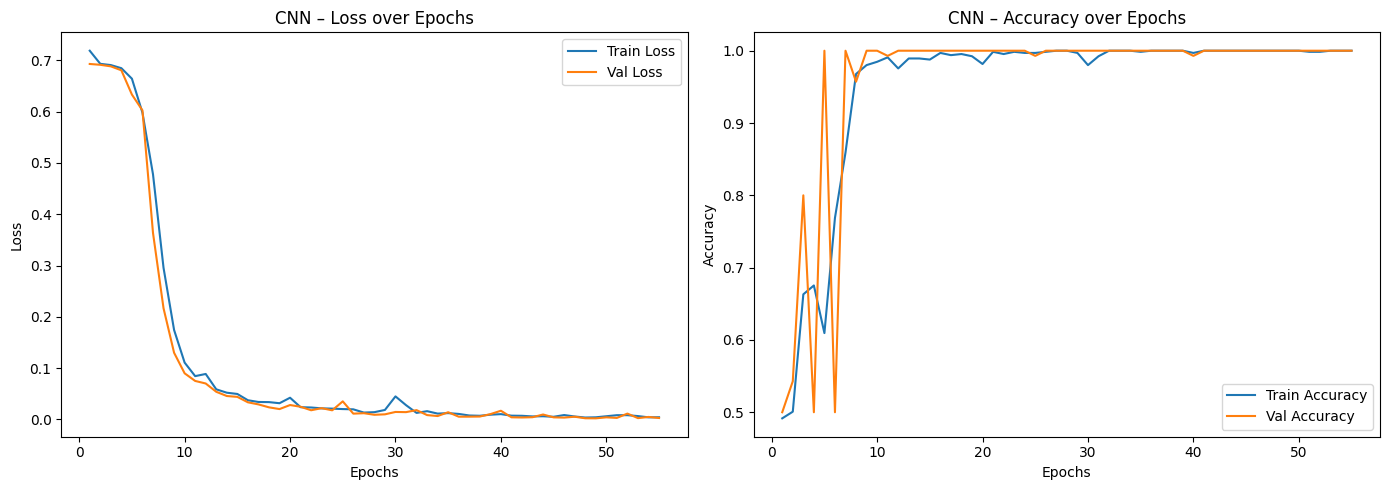

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history_cnn.history['loss']) + 1)
ax1.plot(epochs, history_cnn.history['loss'], label='Train Loss')
ax1.plot(epochs, history_cnn.history['val_loss'], label='Val Loss')
ax1.set_title('CNN – Loss over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, history_cnn.history['accuracy'], label='Train Accuracy')
ax2.plot(epochs, history_cnn.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('CNN – Accuracy over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

#### Confusion Matrix and Metrics on Test Data

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step


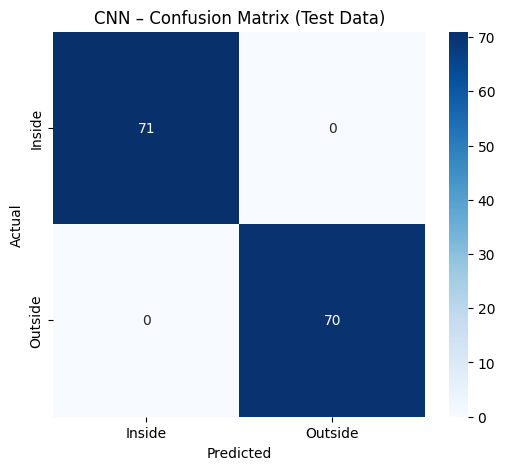

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


In [11]:
y_pred_cnn = cnn_model.predict(test_data)
y_pred_cnn = (y_pred_cnn > 0.5).astype(int).flatten()

cm = confusion_matrix(test_labels, y_pred_cnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Inside', 'Outside'],
            yticklabels=['Inside', 'Outside'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN – Confusion Matrix (Test Data)')
plt.show()

accuracy  = accuracy_score(test_labels, y_pred_cnn)
precision = precision_score(test_labels, y_pred_cnn)
recall    = recall_score(test_labels, y_pred_cnn)
f1        = f1_score(test_labels, y_pred_cnn)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

## Conclusion
FCN Results:

- Accuracy: 0.9291
- Precision: 0.9286
- Recall: 0.9286
- F1 Score: 0.9286

CNN Results:
- Accuracy:  0.9929
- Precision: 0.9859
- Recall:    1.0000
- F1 Score:  0.9929

We clearly see the CNN outperforms the FCN by alot

---

## Question 2

### Load and visualize MNIST data

Training data shape: (60000, 28, 28)
Testing data shape:  (10000, 28, 28)


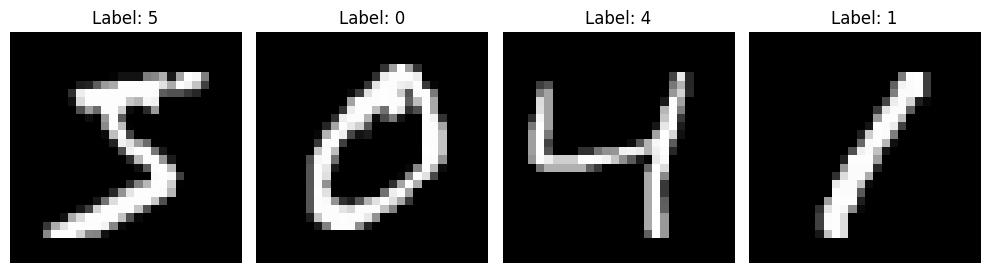

In [12]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test  = x_test  / 255.0

print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape:  {x_test.shape}")

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i in range(4):
    axes[i].imshow(x_train[i], cmap="gray")
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Reshape for CNN 

In [13]:
x_train_cnn = x_train[..., np.newaxis]  # (60000, 28, 28, 1)
x_test_cnn  = x_test[..., np.newaxis]   # (10000, 28, 28, 1)
print(f"CNN Training shape: {x_train_cnn.shape}")
print(f"CNN Testing shape:  {x_test_cnn.shape}")

CNN Training shape: (60000, 28, 28, 1)
CNN Testing shape:  (10000, 28, 28, 1)


### FCN Architecture (from Assignment 6)

In [14]:
fcn_model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

fcn_model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/home/ardo/mlem/Study/Sem8/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
history_fcn = fcn_model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    verbose=1
)

fcn_test_loss, fcn_test_acc = fcn_model.evaluate(x_test, y_test, verbose=0)
print(f'FCN Test accuracy: {fcn_test_acc:.4f}')

Epoch 1/10


2026-03-19 18:38:23.217013: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.
2026-03-19 18:38:23.430499: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


1866/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8649 - loss: 0.4833

2026-03-19 18:38:29.344250: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 31360000 exceeds 10% of free system memory.
2026-03-19 18:38:29.375002: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 31360000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9139 - loss: 0.3045 - val_accuracy: 0.9463 - val_loss: 0.1812
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9550 - loss: 0.1562 - val_accuracy: 0.9595 - val_loss: 0.1342
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9661 - loss: 0.1178 - val_accuracy: 0.9659 - val_loss: 0.1154
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9713 - loss: 0.0975 - val_accuracy: 0.9689 - val_loss: 0.1158
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9751 - loss: 0.0850 - val_accuracy: 0.9713 - val_loss: 0.1025
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9778 - loss: 0.0761 - val_accuracy: 0.9691 - val_loss: 0.1073
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9804 - loss: 0.0683 - val_accuracy: 0.9710 - val_loss: 0.1036
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9822 - loss: 0.0619 - val_accurac

2026-03-19 18:39:44.173598: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 31360000 exceeds 10% of free system memory.


FCN Test accuracy: 0.9749


### CNN Model for MNIST

In [16]:
mnist_cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

mnist_cnn.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history_mnist_cnn = mnist_cnn.fit(
    x_train_cnn, y_train,
    epochs=10,
    validation_data=(x_test_cnn, y_test),
    verbose=1
)

cnn_mnist_loss, cnn_mnist_acc = mnist_cnn.evaluate(x_test_cnn, y_test, verbose=0)
print(f'CNN Test accuracy: {cnn_mnist_acc:.4f}')

Epoch 1/10


2026-03-19 18:39:48.140267: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,26,26]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,1,28,28]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-19 18:39:48.164159: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,11,11]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,13,13]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationFor

1868/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9057 - loss: 0.3008

2026-03-19 18:39:57.253820: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,26,26]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,1,28,28]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-19 18:39:57.281825: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,11,11]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,13,13]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationFor

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9576 - loss: 0.1361 - val_accuracy: 0.9833 - val_loss: 0.0499
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9869 - loss: 0.0442 - val_accuracy: 0.9886 - val_loss: 0.0334
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9900 - loss: 0.0324 - val_accuracy: 0.9888 - val_loss: 0.0350
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9925 - loss: 0.0244 - val_accuracy: 0.9915 - val_loss: 0.0270
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9942 - loss: 0.0193 - val_accuracy: 0.9890 - val_loss: 0.0357
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9955 - loss: 0.0154 - val_accuracy: 0.9914 - val_loss: 0.0300
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9963 - loss: 0.0123 - val_accuracy: 0.9892 - val_loss: 0.0435
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9971 - loss: 0.0098 - val_

### Performance Comparison: FCN vs CNN on MNIST

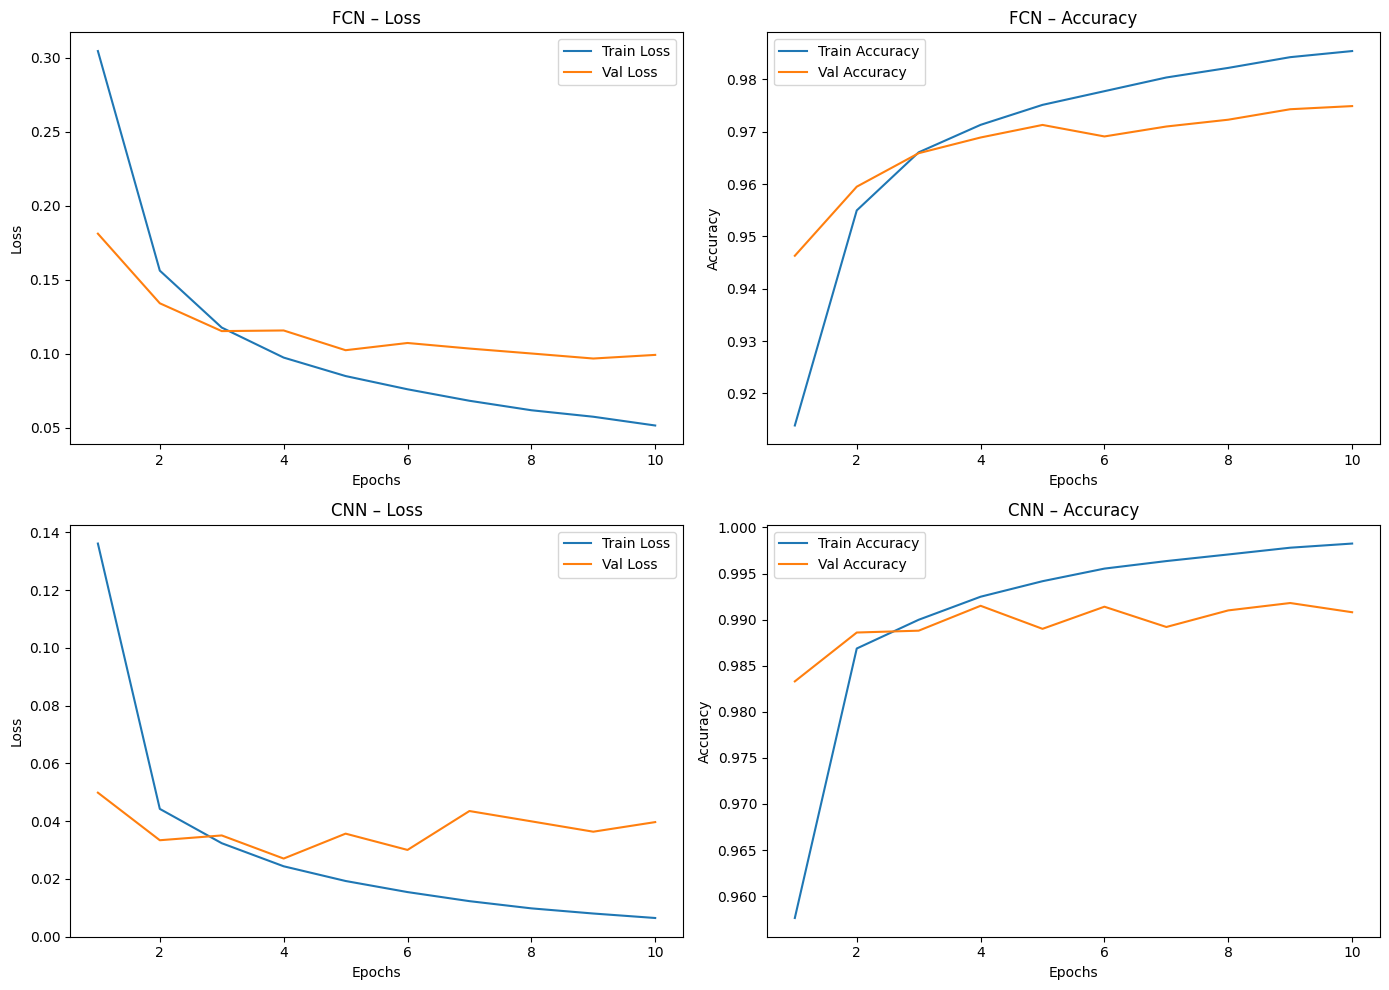

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# FCN Loss
epochs_fcn = range(1, len(history_fcn.history['loss']) + 1)
axes[0, 0].plot(epochs_fcn, history_fcn.history['loss'], label='Train Loss')
axes[0, 0].plot(epochs_fcn, history_fcn.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('FCN – Loss')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# FCN Accuracy
axes[0, 1].plot(epochs_fcn, history_fcn.history['accuracy'], label='Train Accuracy')
axes[0, 1].plot(epochs_fcn, history_fcn.history['val_accuracy'], label='Val Accuracy')
axes[0, 1].set_title('FCN - Accuracy')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# CNN Loss
epochs_cnn = range(1, len(history_mnist_cnn.history['loss']) + 1)
axes[1, 0].plot(epochs_cnn, history_mnist_cnn.history['loss'], label='Train Loss')
axes[1, 0].plot(epochs_cnn, history_mnist_cnn.history['val_loss'], label='Val Loss')
axes[1, 0].set_title('CNN – Loss')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()

# CNN Accuracy
axes[1, 1].plot(epochs_cnn, history_mnist_cnn.history['accuracy'], label='Train Accuracy')
axes[1, 1].plot(epochs_cnn, history_mnist_cnn.history['val_accuracy'], label='Val Accuracy')
axes[1, 1].set_title('CNN – Accuracy')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


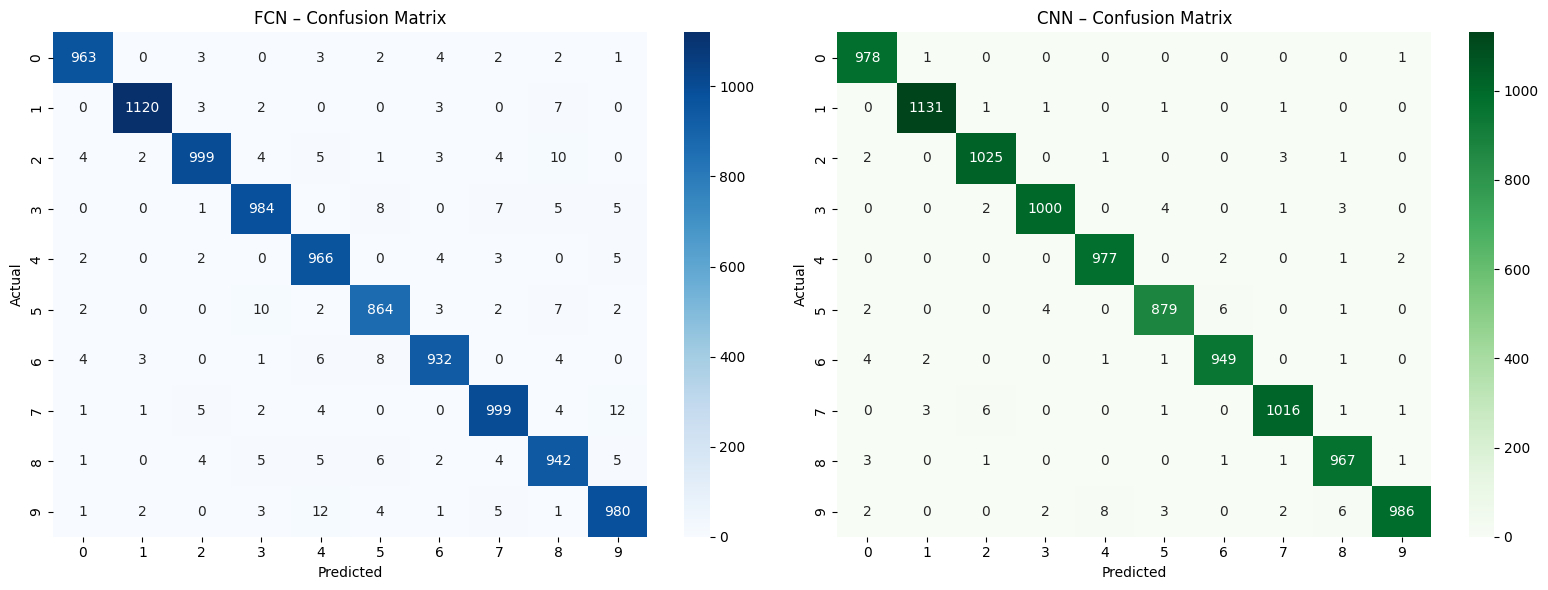

In [19]:
# Confusion matrices side by side
y_pred_fcn = fcn_model.predict(x_test)
y_pred_fcn = np.argmax(y_pred_fcn, axis=1)

y_pred_mnist_cnn = mnist_cnn.predict(x_test_cnn)
y_pred_mnist_cnn = np.argmax(y_pred_mnist_cnn, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

cm_fcn = confusion_matrix(y_test, y_pred_fcn)
sns.heatmap(cm_fcn, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('FCN – Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

cm_cnn = confusion_matrix(y_test, y_pred_mnist_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('CNN – Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 50)
print("MNIST Performance Comparison: FCN vs CNN")
print("=" * 50)
print(f"{'Metric'} {'FCN'} {'CNN'}")
print("-" * 35)
print(f"{'Test Loss: '} {fcn_test_loss:.4}, {cnn_mnist_loss:.4}")
print(f"{'Test Accuracy: '} {fcn_test_acc:.4}, {cnn_mnist_acc:.4}")

fcn_precision = precision_score(y_test, y_pred_fcn, average='weighted')
cnn_precision = precision_score(y_test, y_pred_mnist_cnn, average='weighted')
fcn_recall = recall_score(y_test, y_pred_fcn, average='weighted')
cnn_recall = recall_score(y_test, y_pred_mnist_cnn, average='weighted')
fcn_f1 = f1_score(y_test, y_pred_fcn, average='weighted')
cnn_f1 = f1_score(y_test, y_pred_mnist_cnn, average='weighted')

print(f"{'Precision: '} {fcn_precision:.4}, {cnn_precision:.4}")
print(f"{'Recall: '} {fcn_recall:.4}, {cnn_recall:.4}")
print(f"{'F1 Score: '} {fcn_f1:.4}, {cnn_f1:.4}")
print("=" * 50)

MNIST Performance Comparison: FCN vs CNN
Metric FCN CNN
-----------------------------------
Test Loss:  0.0993, 0.03967
Test Accuracy:  0.9749, 0.9908
Precision:  0.975, 0.9908
Recall:  0.9749, 0.9908
F1 Score:  0.9749, 0.9908


We see CNN also performs better here as the numbered data set has geometrical structures that are better solved/learned via CNNs. As we get:

FCN Accuracy - 0.9749

CNN Accuracy - 0.9908